In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
data = data['2025-03-29 06:00:00':]
data.drop(['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

In [4]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки
data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

In [5]:
portfolio = pd.DataFrame(data=data[['signal', 'open']], index=data.index)

In [13]:
# Ежедневное изменение цены
portfolio['returns'] = data['open'].pct_change()

# Вычисление прибыльности стратегии
portfolio['strategy_returns'] = portfolio['returns'] * portfolio['signal'].shift(1)

cumulative_returns = (portfolio['strategy_returns'] + 1).cumprod()

portfolio['cumulative_returns'] = (portfolio['strategy_returns'] + 1).cumprod()

portfolio['2025-04-06': '2025-09-15'].head(20)
portfolio.tail(20)

,signal,open,returns,strategy_returns,cumulative_returns
timestamp,,,,,
2026-03-11 02:00:00,1,70071.26,0.000377,0.000000,1.026931
2026-03-11 03:00:00,0,69810.73,-0.003718,-0.003718,1.023112
2026-03-11 04:00:00,0,69551.91,-0.003707,-0.000000,1.023112
2026-03-11 05:00:00,0,70130.99,0.008326,0.000000,1.023112
2026-03-11 06:00:00,0,69510.37,-0.008849,-0.000000,1.023112
2026-03-11 07:00:00,0,69950.01,0.006325,0.000000,1.023112
2026-03-11 08:00:00,0,69648.28,-0.004314,-0.000000,1.023112
2026-03-11 09:00:00,0,69662.24,0.000200,0.000000,1.023112
2026-03-11 10:00:00,0,69466.75,-0.002806,-0.000000,1.023112


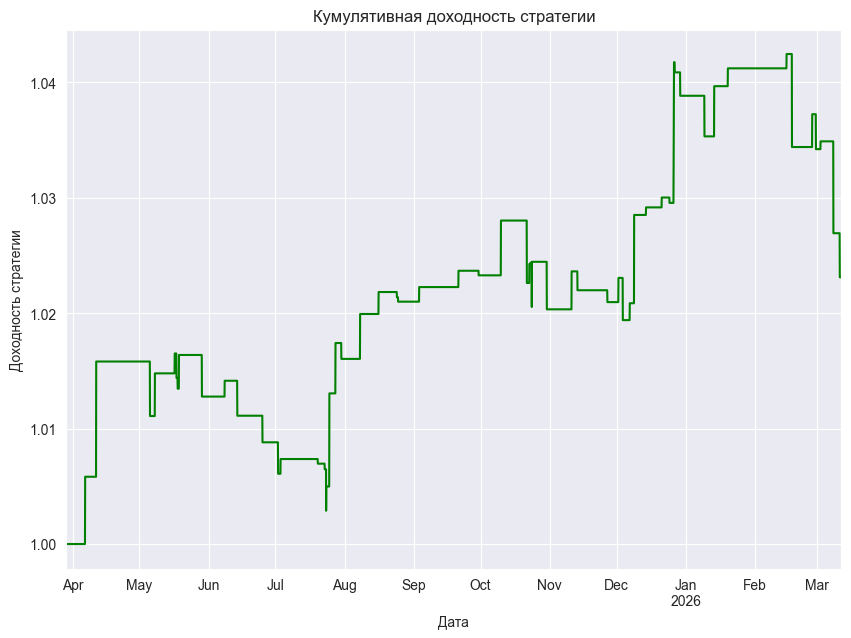

In [7]:
cumulative_returns.plot(figsize=(10, 7), color='green')
plt.title('Кумулятивная доходность стратегии')
plt.xlabel('Дата')
plt.ylabel('Доходность стратегии')
plt.show()

In [8]:
# Ежедневная прибыль
data['returns'] = data['open'].pct_change()

# Вычисление прибыльности стратегии
data['strategy_returns'] = data['returns'] * data['signal'].shift(1)

cumulative_returns = (data['strategy_returns'] + 1).cumprod()

In [9]:
# Общее число торговых дней
days = len(cumulative_returns)

# Вычисление совокупного среднегодового темпа роста
# из расчета 252 торговых дней в год
annualised_returns = (cumulative_returns.iloc[-1]**(252/days)-1)*100

# Ежегодная волатильность
annualised_volatility = np.std(data.strategy_returns)*(252**0.5)*100

# Предполагаемая среднегодовая безрисковая ставка 1%
risk_free_rate = 0.01/252
sharpe_ratio = np.sqrt(252)*(np.mean(data.strategy_returns) -
(risk_free_rate))/np.std(data.strategy_returns)
downside_returns = np.where(data['strategy_returns'] < 0, data['strategy_returns'], 0)
expected_return = np.mean(data['strategy_returns']) - risk_free_rate
downside_risk = np.std(downside_returns) * np.sqrt(252)
sortino_ratio = expected_return / downside_risk

# Текущий максимум
running_max = np.maximum.accumulate(cumulative_returns.dropna())

# Показатель не должен опускаться ниже 1
running_max[running_max < 1] = 1

# Вычисление максимальной просадки
drawdown = (cumulative_returns)/running_max - 1
max_dd = drawdown.min()*100


print(f'Ежегодная доходность стратегии: {annualised_returns:.2f}%\n'
f'Ежегодная волатильность: {annualised_volatility:.2f}%\n'
f'Безрисковая ставка: {risk_free_rate:.8f}\n'
f'Коэффициент Шарпа: {sharpe_ratio:.2f}\n'
f'Максимальная просадка: {max_dd:.2f}%\n'
f'Коэффициент Сортино: {sortino_ratio:.8f}\n'
)

Ежегодная доходность стратегии: 0.07%
Ежегодная волатильность: 0.48%
Безрисковая ставка: 0.00003968
Коэффициент Шарпа: -1.94
Максимальная просадка: -1.86%
Коэффициент Сортино: -0.01211174

